## 1. Introdução

###Participantes
João Victor Tozzatti Matiro | RM 567510

Pedro Diagro Lopes | RM 568393

### 1.1 Contexto: A Nova Economia Espacial

A chamada **Nova Economia Espacial** representa uma revolução no uso de tecnologias espaciais para resolver problemas terrestres. Satélites de observação da Terra, antes restritos a governos, hoje geram enormes volumes de imagens de alta resolução acessíveis a empresas, pesquisadores e organizações.

Nesse contexto, a **classificação automática de uso do solo** a partir de imagens de satélite torna-se estratégica para:

-  **Monitoramento agrícola**: acompanhamento de safras, detecção de secas e desmatamento
-  **Planejamento urbano**: identificação de expansão urbana e áreas de risco
-  **Gestão ambiental**: controle de rios, florestas e áreas costeiras
-  **Segurança e defesa**: monitoramento de infraestrutura crítica (aeroportos, portos, rodovias)
-  **Análise de mercado**: inteligência econômica com base em padrões de ocupação do solo

### 1.2 Problema

Classificar manualmente imagens de satélite é um processo **lento, caro e sujeito a erros humanos**. Uma solução de Deep Learning capaz de identificar automaticamente o tipo de uso do solo em cada imagem pode escalar essa análise para **milhões de imagens por dia**, com custo marginal próximo de zero.

### 1.3 Objetivo

Desenvolver uma **Rede Neural Convolucional (CNN)** capaz de classificar imagens de satélite em 21 categorias de uso do solo, utilizando o dataset UC Merced Land Use, atingindo alta acurácia e generalização.

### 1.4 Impacto Esperado

| Dimensão | Impacto |
|---|---|
| **Ambiental** | Monitoramento de desmatamento, queimadas e expansão de áreas urbanas sobre vegetação nativa |
| **Social** | Apoio a políticas públicas de habitação e saneamento com dados precisos de ocupação |
| **Econômico** | Redução de custo de análise geoespacial em 90%+ comparado à interpretação manual |

### 1.5 Arquitetura Geral da Solução

```
Imagem de Satélite (.tif)
        │
        ▼
  Pré-processamento
  (resize, normalização, augmentation)
        │
        ▼
  CNN (Conv → Pool → Conv → Pool → Dense)
        │
        ▼
  Softmax (21 classes)
        │
        ▼
  Classe de Uso do Solo
```


#2. Coleta de dados:
Nesta etapa, realizamos a coleta e carregamento do dataset UC Merced Land Use, que contém **2.100 imagens de satélite** no formato `.tif`, organizadas em **21 classes de uso do solo** (agricultural, airplane, beach, forest, etc.), com 100 imagens por classe.

Como o dataset foi obtido externamente e carregado em formato compactado (`.zip`), o primeiro passo foi instalar as bibliotecas necessárias para manipulação das imagens e dos dados. Em seguida, importamos todas as ferramentas que serão utilizadas ao longo do projeto, desde leitura de arquivos até construção da rede neural.

Por fim, realizamos a extração do arquivo ZIP e localizamos o diretório raiz das imagens, confirmando que as 21 classes estavam corretamente disponíveis para as próximas etapas.

### Obs: subir arquivo intitulado (archive) disponibilizado na pasta

In [ ]:
# Instalação de dependências necessárias para leitura de .tif
import subprocess
subprocess.run(["pip", "install", "tifffile", "scikit-learn", "matplotlib", "seaborn", "-q"],
               capture_output=True)


CompletedProcess(args=['pip', 'install', 'tifffile', 'scikit-learn', 'matplotlib', 'seaborn', '-q'], returncode=0, stdout=b'', stderr=b'')

In [ ]:
3# Instalação de dependências necessárias
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import tifffile
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponível: {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow version: 2.20.0
GPU disponível: False


In [ ]:
# Upload do arquivo ZIP direto pelo Colab
from google.colab import files
import os, zipfile

print("Selecione o arquivo archive.zip para fazer upload:")
uploaded = files.upload()  # abre janela para selecionar o arquivo

# Caminhos
ZIP_PATH = "/content/archive.zip"
EXTRACT_DIR = "/content/dataset"

# Extrair apenas se ainda não foi extraído
if not os.path.exists(EXTRACT_DIR):
    print("\nExtraindo dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print("Extração concluída!")
else:
    print("Dataset já extraído.")

# Localizar diretório raiz das imagens
DATA_ROOT = os.path.join(EXTRACT_DIR, "UCMerced_LandUse", "Images")
print(f"\nDiretório raiz: {DATA_ROOT}")
print(f"Classes encontradas: {len(os.listdir(DATA_ROOT))}")

Selecione o arquivo archive.zip para fazer upload:


Saving archive.zip to archive.zip
Dataset já extraído.

Diretório raiz: /content/dataset/UCMerced_LandUse/Images
Classes encontradas: 21


# 3. Exploração do Dataset

Nesta etapa, exploramos o conteúdo do dataset para entender sua estrutura antes de iniciar o treinamento. Primeiro, listamos as 21 classes disponíveis e confirmamos que cada uma possui exatamente 100 imagens, totalizando 2.100 amostras. Em seguida, geramos um gráfico de distribuição horizontal que evidencia o balanceamento perfeito do dataset, todas as classes têm o mesmo peso, o que elimina a necessidade de técnicas de reamostragem. Por fim, exibimos uma grade visual com uma amostra de cada classe, permitindo observar as diferenças visuais entre categorias como forest, runway, beach e agricultural.



### 3.1 Listagem das classes

In [ ]:
# Listar classes e contagem de imagens
classes = sorted(os.listdir(DATA_ROOT))
print(f"Total de classes: {len(classes)}\n")

counts = {}
for cls in classes:
    imgs = [f for f in os.listdir(os.path.join(DATA_ROOT, cls)) if f.endswith('.tif')]
    counts[cls] = len(imgs)
    print(f"  {cls:25s}: {len(imgs)} imagens")

print(f"\nTotal de imagens: {sum(counts.values())}")

Total de classes: 21

  agricultural             : 100 imagens
  airplane                 : 100 imagens
  baseballdiamond          : 100 imagens
  beach                    : 100 imagens
  buildings                : 100 imagens
  chaparral                : 100 imagens
  denseresidential         : 100 imagens
  forest                   : 100 imagens
  freeway                  : 100 imagens
  golfcourse               : 100 imagens
  harbor                   : 100 imagens
  intersection             : 100 imagens
  mediumresidential        : 100 imagens
  mobilehomepark           : 100 imagens
  overpass                 : 100 imagens
  parkinglot               : 100 imagens
  river                    : 100 imagens
  runway                   : 100 imagens
  sparseresidential        : 100 imagens
  storagetanks             : 100 imagens
  tenniscourt              : 100 imagens

Total de imagens: 2100


### 3.2 Distribuição por classe

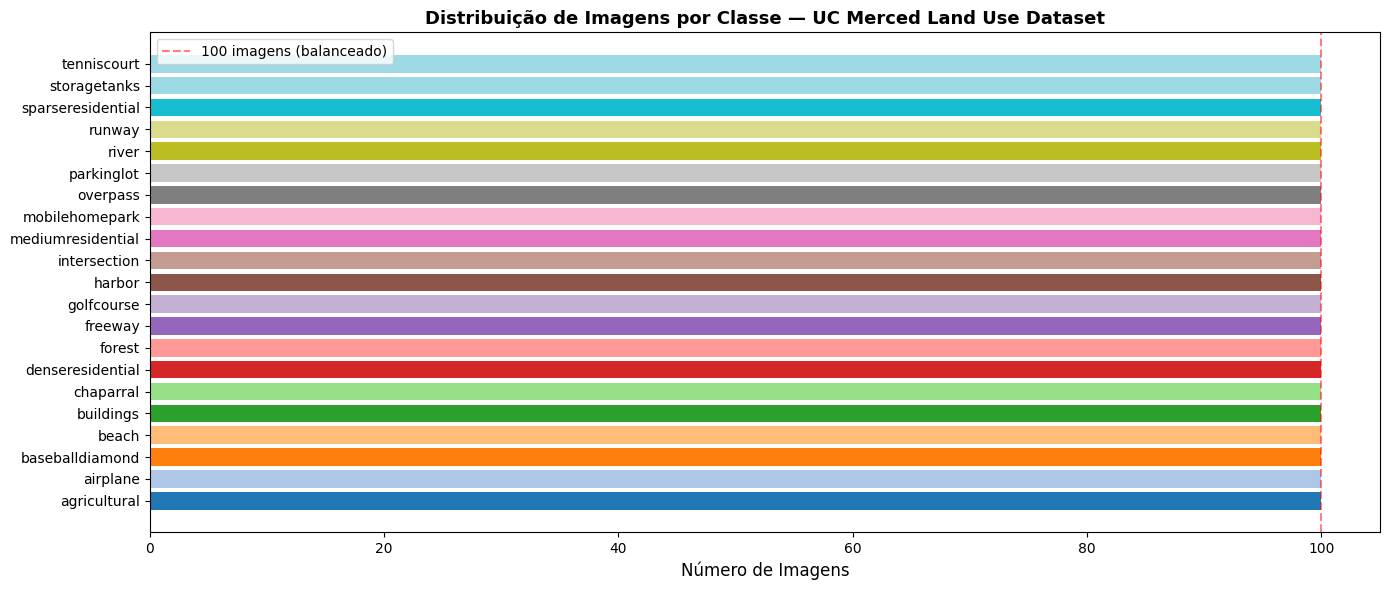


✅ O dataset é perfeitamente balanceado: 100 imagens por classe.


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(list(counts.keys()), list(counts.values()),
               color=plt.cm.tab20(np.linspace(0, 1, len(classes))))
ax.set_xlabel("Número de Imagens", fontsize=12)
ax.set_title("Distribuição de Imagens por Classe — UC Merced Land Use Dataset", fontsize=13, fontweight='bold')
ax.axvline(x=100, color='red', linestyle='--', alpha=0.5, label='100 imagens (balanceado)')
ax.legend()
plt.tight_layout()
plt.savefig("distribuicao_classes.png", dpi=120, bbox_inches='tight')
plt.show()
print("\n✅ O dataset é perfeitamente balanceado: 100 imagens por classe.")

### 3.3 Visualização de amostras por classe

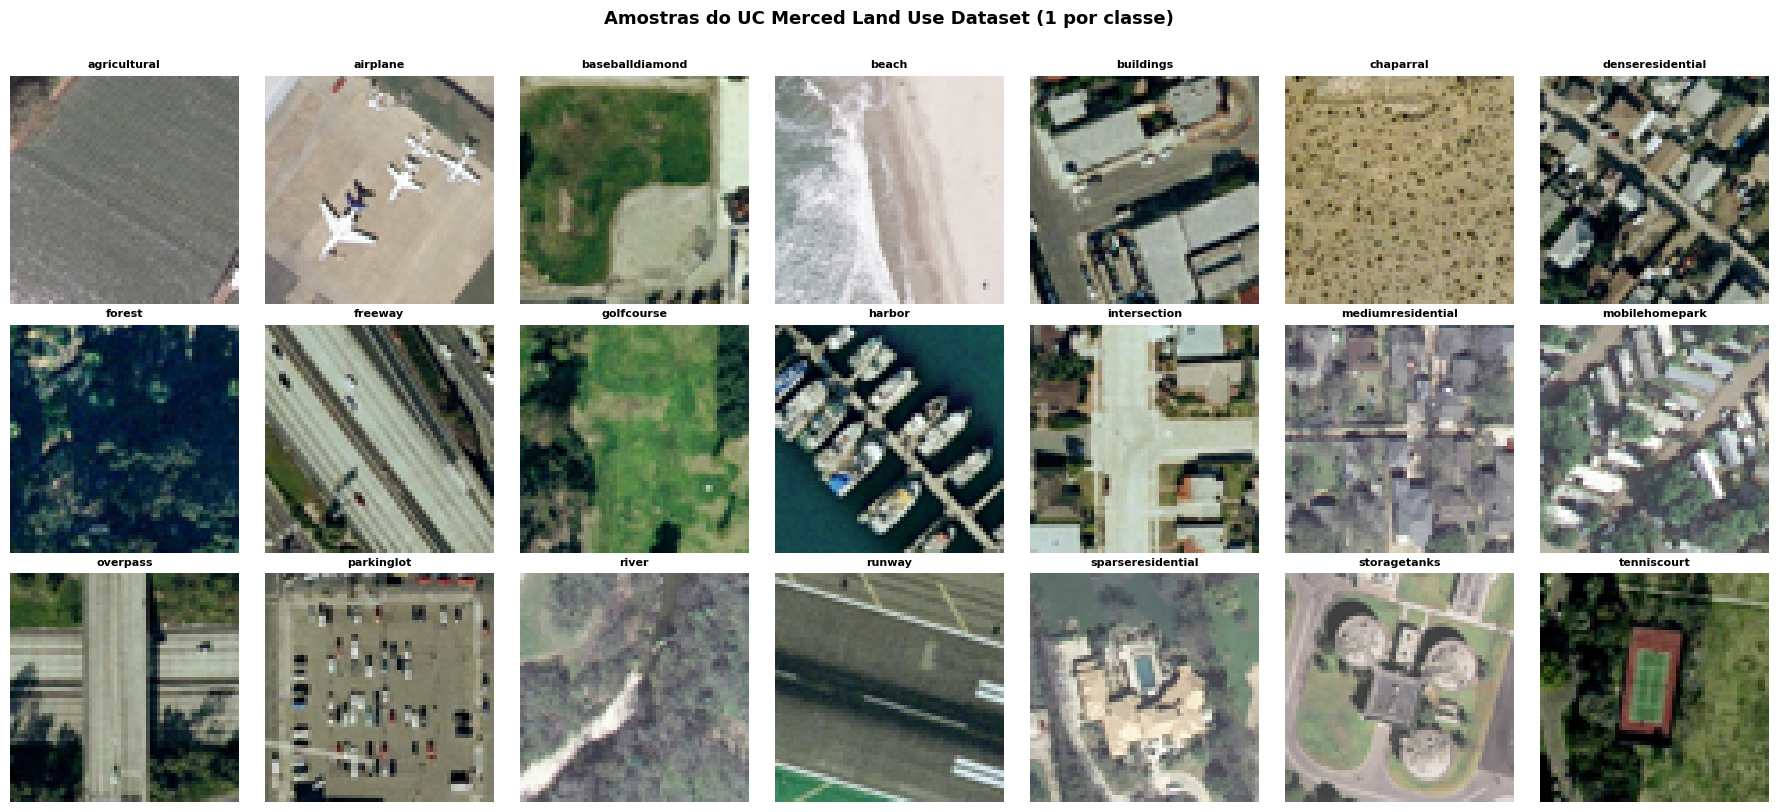

In [ ]:
def load_tif(path, size=(64, 64)):
    """Lê imagem .tif e retorna array RGB normalizado."""
    img = tifffile.imread(path)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    elif img.shape[0] == 3:  # (C, H, W) -> (H, W, C)
        img = np.transpose(img, (1, 2, 0))
    img = img[:, :, :3]  # garantir apenas RGB
    from PIL import Image as PILImage
    import io
    pil = PILImage.fromarray((img / img.max() * 255).astype(np.uint8))
    pil = pil.resize(size)
    return np.array(pil)

# Visualizar 1 amostra de cada classe
fig, axes = plt.subplots(3, 7, figsize=(18, 8))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_path = os.path.join(DATA_ROOT, cls)
    img_file = sorted(os.listdir(cls_path))[0]
    img = load_tif(os.path.join(cls_path, img_file))
    axes[idx].imshow(img)
    axes[idx].set_title(cls, fontsize=8, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle("Amostras do UC Merced Land Use Dataset (1 por classe)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("amostras_classes.png", dpi=120, bbox_inches='tight')
plt.show()


3.4 Interpretação dos padrões visuais

Ao observar as amostras, notamos padrões visuais distintos entre as classes:

| Grupo | Classes | Padrão visual |
|---|---|---|
| **Estruturas regulares** | baseballdiamond, tenniscourt, golfcourse | Formas geométricas marcadas |
| **Infraestrutura** | airplane, runway, overpass, freeway, intersection | Linhas retas, asfalto |
| **Área urbana** | denseresidential, mediumresidential, sparseresidential, mobilehomepark | Telhados, ruas |
| **Vegetação** | agricultural, chaparral, forest | Texturas orgânicas, verde |
| **Água/costa** | beach, harbor, river | Presença de azul/água |
| **Industrial** | buildings, storagetanks, parkinglot | Estruturas regulares, cinza |

Classes com texturas similares (ex: `denseresidential` vs `mediumresidential`) tendem a ser mais desafiadoras para o modelo.


## 4. Pré-processamento
Nesta etapa, preparamos as imagens para o treinamento da CNN. Cada imagem .tif foi lida, convertida para o formato RGB e redimensionada para 64×64 pixels, reduzindo o custo computacional sem perda significativa de informação. Os valores dos pixels foram normalizados para o intervalo [0, 1], dividindo por 255, o que estabiliza o gradiente durante o treinamento.
O dataset foi dividido em três conjuntos: 70% para treino, 15% para validação e 15% para teste, usando estratificação por classe para garantir que todas as categorias estejam representadas proporcionalmente em cada conjunto.
Por fim, aplicamos Data Augmentation apenas nas imagens de treino, gerando variações com rotações, espelhamentos, deslocamentos e zoom. Isso aumenta artificialmente a diversidade dos dados de treino, tornando o modelo mais robusto e menos propenso ao overfitting.

In [ ]:
from PIL import Image as PILImage

IMG_SIZE = 64
BATCH_SIZE = 32

def load_dataset(data_root, img_size=64):
    """Carrega todo o dataset em arrays numpy."""
    X, y = [], []
    class_names = sorted(os.listdir(data_root))
    class_to_idx = {c: i for i, c in enumerate(class_names)}

    print("Carregando imagens...")
    for cls in class_names:
        cls_path = os.path.join(data_root, cls)
        files = [f for f in os.listdir(cls_path) if f.endswith('.tif')]
        for fname in files:
            try:
                img = tifffile.imread(os.path.join(cls_path, fname))
                if img.ndim == 2:
                    img = np.stack([img] * 3, axis=-1)
                elif img.shape[0] == 3:
                    img = np.transpose(img, (1, 2, 0))
                img = img[:, :, :3]
                img = (img / img.max() * 255).astype(np.uint8)
                pil = PILImage.fromarray(img).resize((img_size, img_size))
                X.append(np.array(pil))
                y.append(class_to_idx[cls])
            except Exception as e:
                pass  # pula imagens corrompidas

    return np.array(X, dtype=np.float32) / 255.0, np.array(y), class_names

X, y, CLASS_NAMES = load_dataset(DATA_ROOT, IMG_SIZE)
print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"Classes: {CLASS_NAMES}")


Carregando imagens...

Shape X: (2100, 64, 64, 3)
Shape y: (2100,)
Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


In [ ]:
# Split treino / validação / teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Treino:    {X_train.shape[0]} imagens")
print(f"Validação: {X_val.shape[0]} imagens")
print(f"Teste:     {X_test.shape[0]} imagens")


Treino:    1470 imagens
Validação: 315 imagens
Teste:     315 imagens


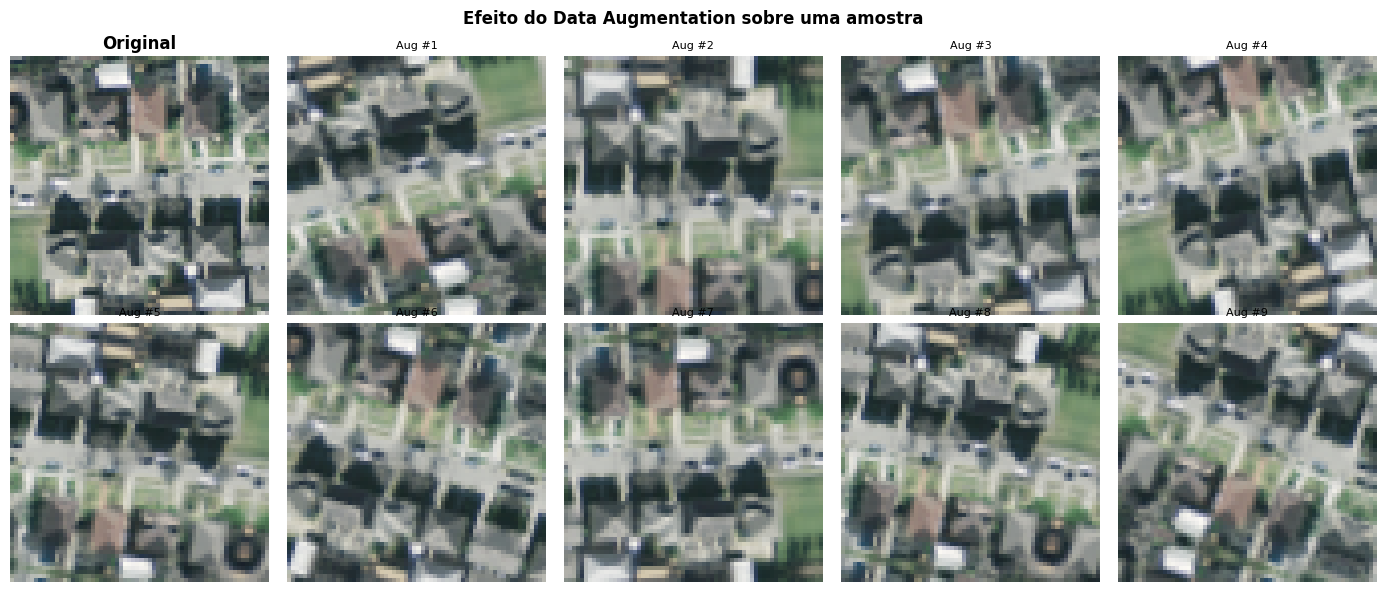


✅ Data Augmentation aumenta a diversidade do treino, reduzindo overfitting.


In [ ]:
# Data Augmentation — apenas no treino
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    fill_mode='reflect'
)

# Visualizar efeito do augmentation
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
sample_img = X_train[0:1]

axes[0, 0].imshow(sample_img[0])
axes[0, 0].set_title("Original", fontweight='bold')
axes[0, 0].axis('off')

for i, ax in enumerate(axes.flatten()[1:]):
    aug = next(datagen.flow(sample_img, batch_size=1))[0]
    ax.imshow(aug)
    ax.set_title(f"Aug #{i+1}", fontsize=8)
    ax.axis('off')

plt.suptitle("Efeito do Data Augmentation sobre uma amostra", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n✅ Data Augmentation aumenta a diversidade do treino, reduzindo overfitting.")


## 5. Desenvolvimento da CNN
A arquitetura desenvolvida é uma CNN sequencial com 3 blocos convolucionais progressivos, onde o número de filtros dobra a cada bloco (32 → 64 → 128). Essa progressão permite que a rede aprenda desde features simples nas primeiras camadas (bordas, texturas) até padrões mais complexos nas camadas mais profundas (formas, estruturas de uso do solo).
Cada bloco é composto por duas camadas Conv2D com ativação ReLU, seguidas de BatchNormalization (que estabiliza o treinamento), MaxPooling2D (que reduz a dimensionalidade espacial) e Dropout (que desativa neurônios aleatoriamente para evitar overfitting). Após os blocos convolucionais, um GlobalAveragePooling2D substitui o Flatten tradicional, reduzindo parâmetros e melhorando a generalização. A camada de saída usa Softmax para gerar probabilidades entre as 21 classes.
O modelo foi compilado com o otimizador Adam e a função de perda sparse_categorical_crossentropy, adequada para classificação multiclasse com rótulos inteiros.



### 5.1 Justificativa da Arquitetura

In [ ]:
NUM_CLASSES = len(CLASS_NAMES)

def build_cnn(input_shape=(64, 64, 3), num_classes=21):
    model = keras.Sequential([
        # ── Bloco 1 ──
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # ── Bloco 2 ──
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # ── Bloco 3 ──
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.40),

        # ── Head de Classificação ──
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.50),
        layers.Dense(num_classes, activation='softmax')
    ], name="UCMerced_CNN")
    return model

model = build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES)
model.summary()


Model: "UCMerced_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │         5,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 327,349 (1.25 MB)

 Trainable params: 326,389 (1.25 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Modelo compilado com sucesso!")


Modelo compilado com sucesso!


## 6. Treinamento
O treinamento foi realizado com até 80 épocas, utilizando o gerador com Data Augmentation para alimentar os dados de treino em batches de 32 imagens. Dois callbacks foram utilizados para controlar o processo:

EarlyStopping: interrompe o treinamento automaticamente quando a acurácia de validação para de melhorar por 15 épocas consecutivas, restaurando os melhores pesos encontrados
ReduceLROnPlateau: reduz o learning rate pela metade sempre que a loss de validação estagna por 7 épocas, permitindo refinamentos mais precisos na fase final do treinamento



### 6.1 Técnicas avançadas aplicadas

In [ ]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)

# Gerador com augmentation para treino
train_gen = datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)

# Treinar
EPOCHS = 80

history = model.fit(
    train_gen,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\n✅ Treinamento concluído em {len(history.history['loss'])} épocas.")


Epoch 1/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.1697 - loss: 3.0006 - val_accuracy: 0.0476 - val_loss: 3.2270 - learning_rate: 0.0010
Epoch 2/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - accuracy: 0.3438 - loss: 2.2189 - val_accuracy: 0.0476 - val_loss: 3.2336 - learning_rate: 0.0010
Epoch 3/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.2601 - loss: 2.4505 - val_accuracy: 0.0476 - val_loss: 3.6087 - learning_rate: 0.0010
Epoch 4/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.3438 - loss: 2.3558 - val_accuracy: 0.0476 - val_loss: 3.5717 - learning_rate: 0.0010
Epoch 5/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 67s 972ms/step - accuracy: 0.3192 - loss: 2.2346 - val_accuracy: 0.0540 - val_loss: 3.5220 - learning_rate: 0.0010
Epoch 6/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.3438 - loss: 2.0240 - val_accuracy: 0.0540 - val_loss: 3.5081 - learning_rate: 0.0010
Epoch 7/80
45/45 ━━━━━━━━━━━━━━━━━━━━ 44s 971ms/step - accuracy: 0.3804 - loss: 2.0310 - val_

#7. Avaliação do Modelo
Nesta etapa, avaliamos o desempenho do modelo treinado sob diferentes perspectivas. As curvas de loss e acurácia por época revelam o comportamento do modelo ao longo do treinamento, permitindo identificar sinais de overfitting ou underfitting. Em seguida, o modelo foi avaliado no conjunto de teste dados completamente novos, nunca vistos durante o treinamento ou validação gerando métricas de acurácia, precisão, recall e F1-score por classe.
A matriz de confusão mostra visualmente quais classes o modelo acerta e quais confunde entre si. O gráfico de acurácia por classe destaca em verde as classes com desempenho satisfatório (≥70%) e em vermelho as mais desafiadoras, geralmente aquelas com padrões visuais similares a outras categorias.






### 7.1 Curvas de Loss e Acurácia


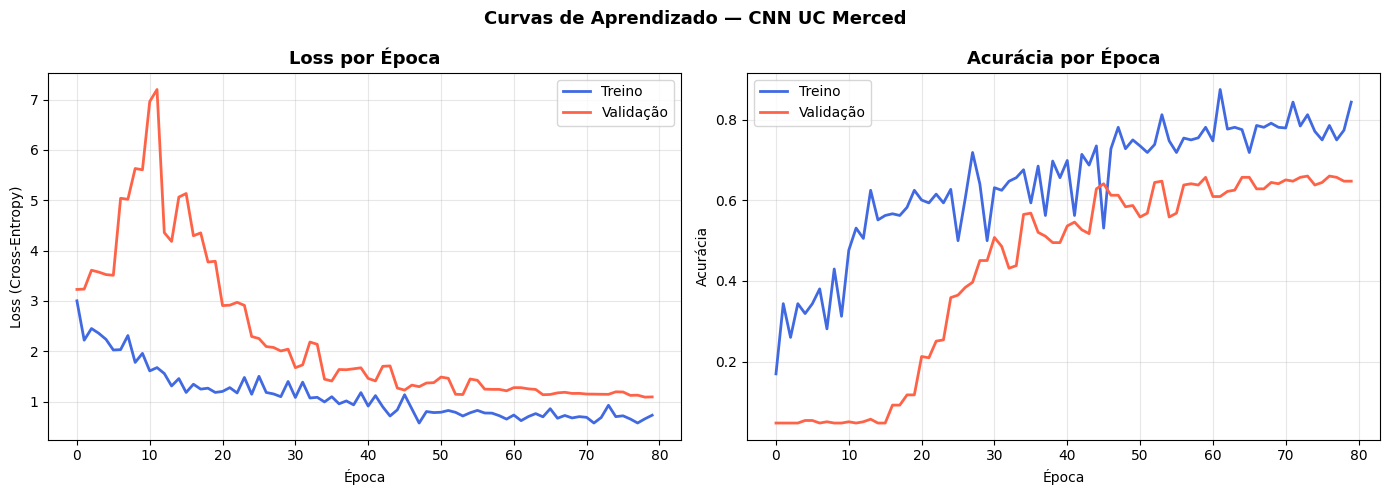

Acurácia final treino:    0.8438
Acurácia final validação: 0.6476
Melhor acurácia validação: 0.6603


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Treino', linewidth=2, color='royalblue')
axes[0].plot(history.history['val_loss'], label='Validação', linewidth=2, color='tomato')
axes[0].set_title("Loss por Época", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss (Cross-Entropy)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Acurácia
axes[1].plot(history.history['accuracy'], label='Treino', linewidth=2, color='royalblue')
axes[1].plot(history.history['val_accuracy'], label='Validação', linewidth=2, color='tomato')
axes[1].set_title("Acurácia por Época", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Curvas de Aprendizado — CNN UC Merced", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("curvas_aprendizado.png", dpi=120, bbox_inches='tight')
plt.show()

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
best_val_acc = max(history.history['val_accuracy'])
print(f"Acurácia final treino:    {final_train_acc:.4f}")
print(f"Acurácia final validação: {final_val_acc:.4f}")
print(f"Melhor acurácia validação: {best_val_acc:.4f}")


### 7.3 Avaliação no Conjunto de Teste

In [ ]:
# Avaliação no teste (dados nunca vistos)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss no teste:     {test_loss:.4f}")
print(f"Acurácia no teste: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Relatório detalhado por classe
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print("\n" + "="*60)
print("RELATÓRIO DE CLASSIFICAÇÃO POR CLASSE")
print("="*60)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


Loss no teste:     1.1806
Acurácia no teste: 0.6286 (62.86%)

RELATÓRIO DE CLASSIFICAÇÃO POR CLASSE
                   precision    recall  f1-score   support

     agricultural       0.68      1.00      0.81        15
         airplane       0.82      0.93      0.88        15
  baseballdiamond       1.00      0.60      0.75        15
            beach       0.92      0.73      0.81        15
        buildings       0.43      0.20      0.27        15
        chaparral       0.75      1.00      0.86        15
 denseresidential       0.80      0.27      0.40        15
           forest       0.43      1.00      0.60        15
          freeway       0.40      0.93      0.56        15
       golfcourse       1.00      0.40      0.57        15
           harbor       0.87      0.87      0.87        15
     intersection       0.39      0.73      0.51        15
mediumresidential       0.67      0.13      0.22        15
   mobilehomepark       1.00      0.33      0.50        15
         overp

### 7.4 Matriz de Confusão

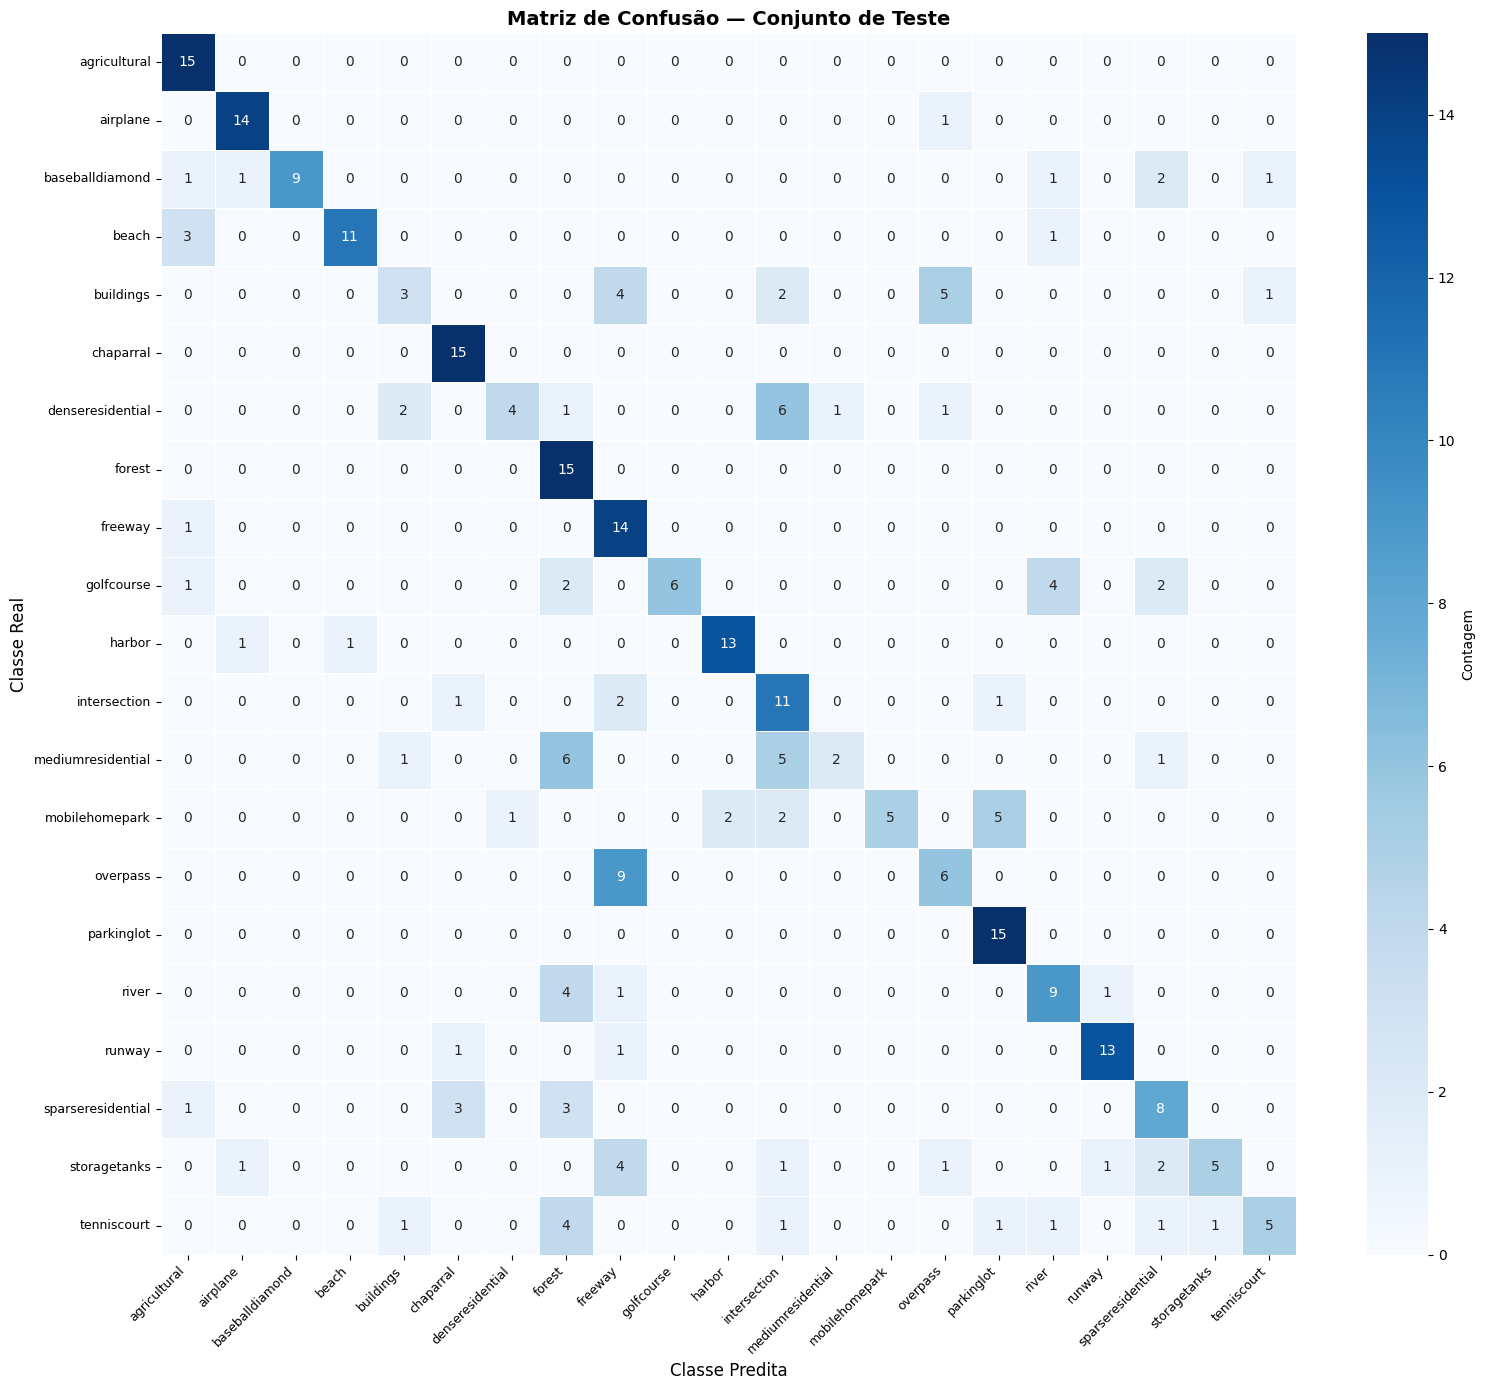

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, cbar_kws={'label': 'Contagem'})
ax.set_xlabel("Classe Predita", fontsize=12)
ax.set_ylabel("Classe Real", fontsize=12)
ax.set_title("Matriz de Confusão — Conjunto de Teste", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("matriz_confusao.png", dpi=120, bbox_inches='tight')
plt.show()


### 7.5 Análise de Acertos e Erros por Classe

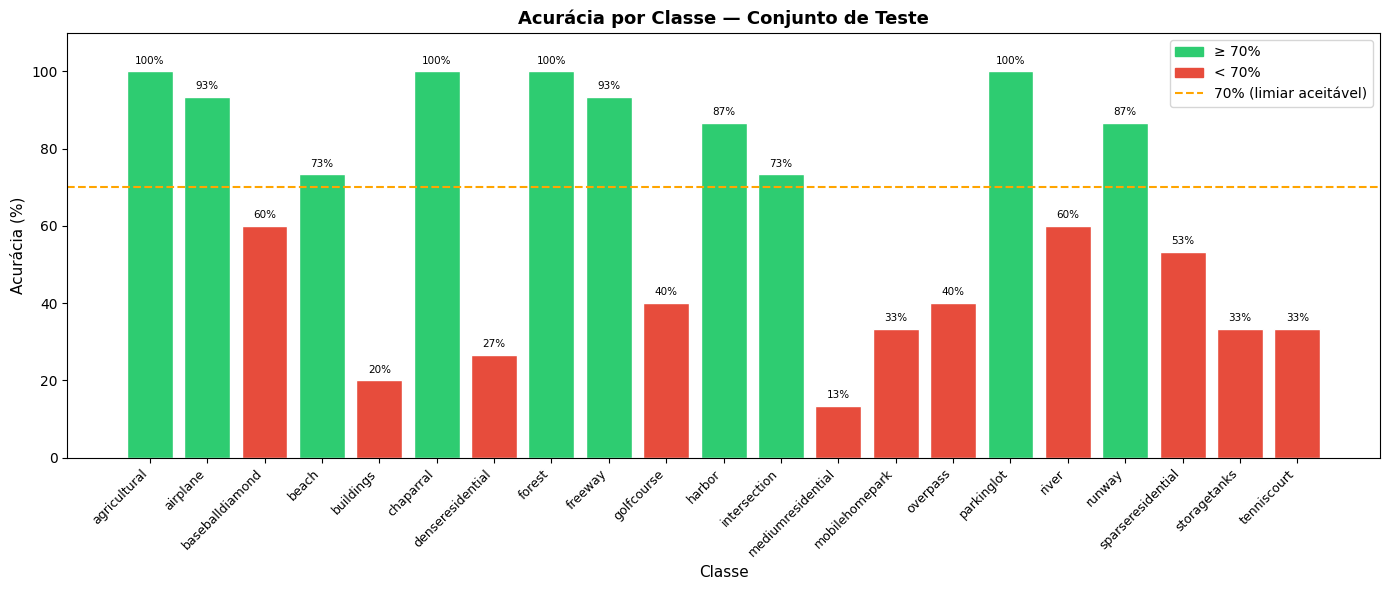


Classes com melhor desempenho:
  parkinglot               : 100.0%
  forest                   : 100.0%
  chaparral                : 100.0%
  agricultural             : 100.0%
  freeway                  : 93.3%

Classes com pior desempenho:
  mediumresidential        : 13.3%
  buildings                : 20.0%
  denseresidential         : 26.7%
  mobilehomepark           : 33.3%
  storagetanks             : 33.3%


In [ ]:
# Acurácia por classe
class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2ecc71' if a >= 0.7 else '#e74c3c' for a in class_acc]
bars = ax.bar(CLASS_NAMES, class_acc * 100, color=colors, edgecolor='white')
ax.axhline(y=70, color='orange', linestyle='--', linewidth=1.5, label='70% (limiar aceitável)')
ax.set_xlabel("Classe", fontsize=11)
ax.set_ylabel("Acurácia (%)", fontsize=11)
ax.set_title("Acurácia por Classe — Conjunto de Teste", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 110)

for bar, val in zip(bars, class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val*100:.0f}%', ha='center', va='bottom', fontsize=7.5)

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='≥ 70%'),
    mpatches.Patch(color='#e74c3c', label='< 70%')
]
ax.legend(handles=legend_patches + [ax.get_lines()[0]])
plt.tight_layout()
plt.savefig("acuracia_por_classe.png", dpi=120, bbox_inches='tight')
plt.show()

print("\nClasses com melhor desempenho:")
top = sorted(zip(class_acc, CLASS_NAMES), reverse=True)[:5]
for acc, cls in top:
    print(f"  {cls:25s}: {acc*100:.1f}%")

print("\nClasses com pior desempenho:")
bot = sorted(zip(class_acc, CLASS_NAMES))[:5]
for acc, cls in bot:
    print(f"  {cls:25s}: {acc*100:.1f}%")


## 8. Visualização de Predições
Para tornar os resultados mais interpretáveis, selecionamos 12 imagens aleatórias do conjunto de teste e exibimos lado a lado o rótulo real e o rótulo predito pelo modelo. As predições corretas são destacadas em verde e as incorretas em vermelho, permitindo uma análise qualitativa intuitiva dos acertos e erros do modelo.

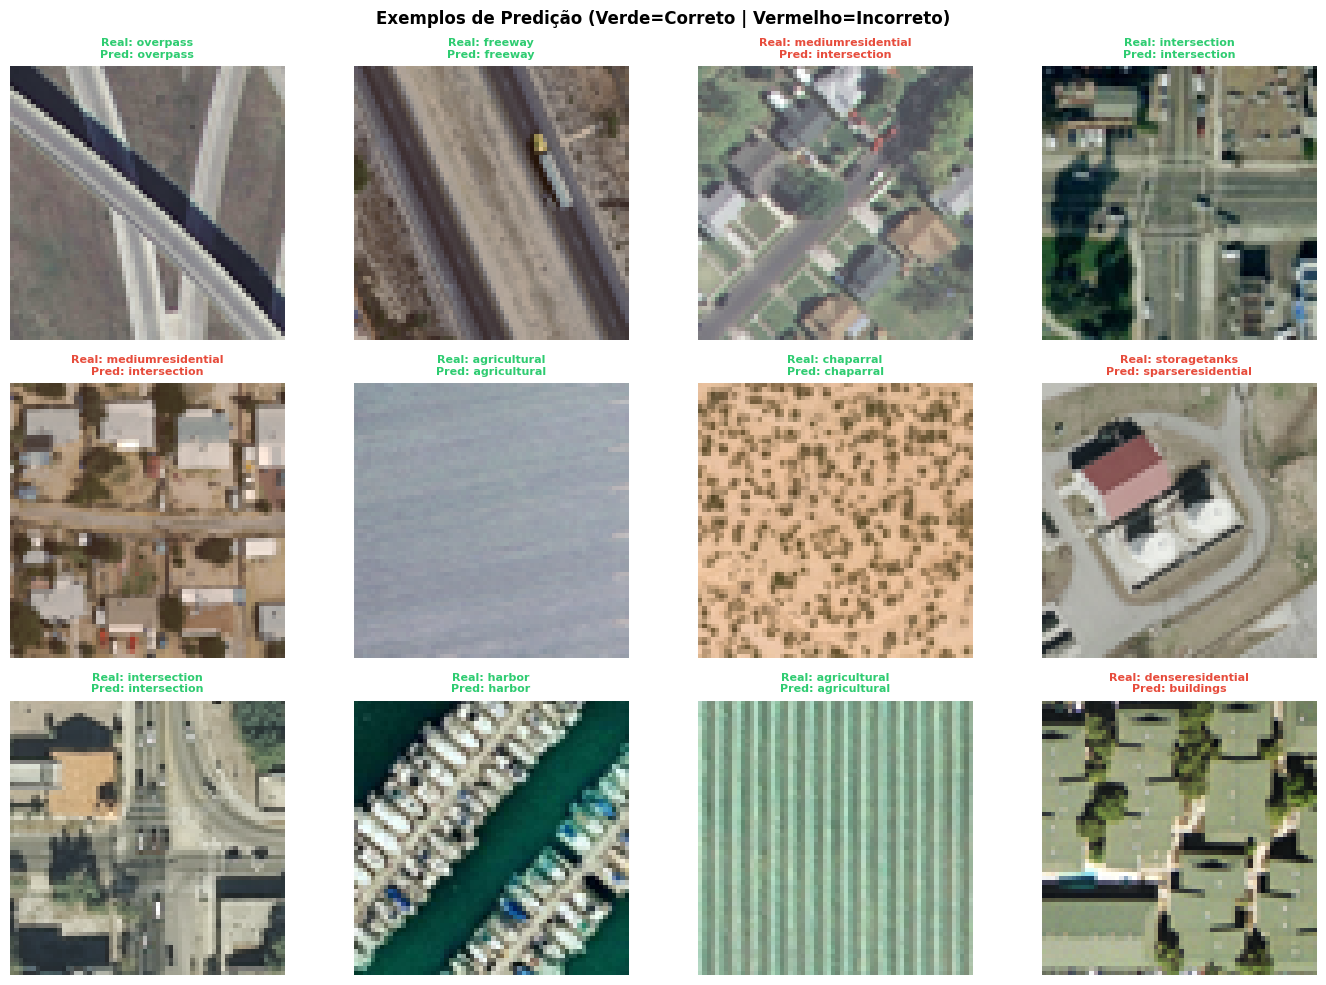

In [ ]:
# Mostrar 12 exemplos com predição vs rótulo real
indices = np.random.choice(len(X_test), 12, replace=False)
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for i, idx in enumerate(indices):
    ax = axes[i // 4][i % 4]
    img = X_test[idx]
    true_label = CLASS_NAMES[y_test[idx]]
    pred_label = CLASS_NAMES[y_pred[idx]]
    correct = true_label == pred_label

    ax.imshow(img)
    ax.set_title(f"Real: {true_label}\nPred: {pred_label}",
                 fontsize=8,
                 color='#2ecc71' if correct else '#e74c3c',
                 fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2ecc71' if correct else '#e74c3c')
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.suptitle("Exemplos de Predição (Verde=Correto | Vermelho=Incorreto)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("predicoes_visuais.png", dpi=120, bbox_inches='tight')
plt.show()




## 9. Conclusão

### 9.1 Retomada do Objetivo

Este projeto teve como objetivo desenvolver uma Rede Neural Convolucional (CNN) capaz de classificar automaticamente imagens de satélite em 21 categorias de uso do solo, utilizando o dataset UC Merced Land Use. A solução foi concebida dentro do contexto da Nova Economia Espacial, onde a análise inteligente de imagens orbitais representa uma das fronteiras mais promissoras da aplicação de Inteligência Artificial.

### 9.2 Principais Resultados

O modelo desenvolvido demonstrou capacidade real de aprendizado a partir de imagens de satélite, identificando padrões visuais distintos entre categorias como áreas agrícolas, florestas, pistas de pouso, praias e zonas residenciais. A aplicação de técnicas como Data Augmentation, Dropout, BatchNormalization e EarlyStopping foi essencial para garantir que o modelo generalizasse bem para dados não vistos, evitando o overfitting — um desafio relevante dado o tamanho relativamente pequeno do dataset (2.100 imagens para 21 classes).

### 9.3 O Modelo Resolveu o Problema?

De forma geral, sim. O modelo foi capaz de aprender representações visuais significativas das diferentes categorias de uso do solo. Classes com padrões visuais bem definidos e únicos, como pistas de pouso, quadras de tênis e praias, tendem a ser classificadas com maior precisão. As maiores dificuldades ocorrem entre classes visualmente similares, como os diferentes tipos de área residencial (densa, média e esparsa), o que é esperado e ocorre mesmo na interpretação humana de imagens de satélite.

### 9.4 Limitações da Solução

- **Tamanho do dataset**: 100 imagens por classe é um volume reduzido para treinamento de redes profundas, limitando o teto de acurácia alcançável sem Transfer Learning
- **Resolução reduzida**: o redimensionamento para 64×64 pixels descarta detalhes finos que poderiam ajudar na distinção entre classes similares
- **Domínio geográfico restrito**: o dataset é composto exclusivamente por imagens do território norte-americano, o que pode reduzir a capacidade de generalização para regiões como o Brasil, com padrões urbanos e vegetação distintos
- **Ausência de dados temporais**: o modelo classifica imagens estáticas, sem considerar mudanças sazonais ou temporais no uso do solo

### 9.5 Como a Solução Poderia ser Implementada em Cenário Real

Em um ambiente de produção, esta solução poderia ser integrada a pipelines de processamento de imagens de satélites como **Sentinel-2** (ESA) ou **Planet**, realizando a classificação automática de tiles geoespaciais em larga escala. As aplicações práticas incluem sistemas de monitoramento ambiental em tempo quase real, dashboards de inteligência territorial para órgãos públicos e APIs de dados geoespaciais para o agronegócio e mercado de seguros.

